# Fighting Overfitting — add BatchNorm + Dropout to `MyNN`, plus weight decay (L2)

In the Last demo, our `MyNN` network overfit: ~98% train accuracy but only ~89% test accuracy.

Here we keep **everything the same** (same widths, same lr=0.1, same 100 epochs, same training loop) and change **only the regularization**:
1. First we train the **original `MyNN`** as a baseline.
2. Then we add `nn.BatchNorm1d()` and `nn.Dropout()` **directly inside the same `MyNN` class**, switch on `weight_decay` (L2) in the optimizer, and train again.
3. Finally we print both train/test gaps **side by side**.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)


In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


## Load the data
Same Fashion-MNIST training file as the GPU demo.

In [ ]:
# Fetches directly (no upload). Note: LFS 'media' host, not 'raw'.
url = 'https://media.githubusercontent.com/media/fpleoni/fashion_mnist/master/fashion-mnist_train.csv'
df = pd.read_csv(url)

# --- Alternatives ---
# Colab upload:  df = pd.read_csv('/content/fashion-mnist_train.csv')
# Local file:    df = pd.read_csv('fashion-mnist_train.csv')
df.head()


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# scale pixels to 0-1
X_train = X_train/255.0
X_test = X_test/255.0


In [ ]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]


In [ ]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)


## Step 1 — Baseline `MyNN` (no regularization)
The same network from the GPU demo. It will overfit.

In [ ]:
class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):

    return self.model(x)


In [ ]:
learning_rate = 0.1
epochs = 100


In [ ]:
# instantiate + train the baseline
model = MyNN(X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)  # no weight_decay -> no L2

for epoch in range(epochs):
  model.train()  # training mode (Dropout on, BatchNorm updates)
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = model(batch_features)
    loss = criterion(outputs, batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss += loss.item()
  if (epoch + 1) % 10 == 0:
    print(f'Epoch: {epoch + 1} , Loss: {total_epoch_loss/len(train_loader):.4f}')


Epoch: 10 , Loss: 0.2747
Epoch: 20 , Loss: 0.2096
Epoch: 30 , Loss: 0.1704
Epoch: 40 , Loss: 0.1423
Epoch: 50 , Loss: 0.1197
Epoch: 60 , Loss: 0.0992
Epoch: 70 , Loss: 0.0894
Epoch: 80 , Loss: 0.0773
Epoch: 90 , Loss: 0.0712
Epoch: 100 , Loss: 0.0621


Evaluate the baseline on train vs test.

In [ ]:
model.eval()  # evaluation mode (Dropout off, BatchNorm uses running stats)

# accuracy on TRAIN data (data the model has seen)
correct = 0
total = 0
with torch.no_grad():
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    _, predicted = torch.max(model(batch_features), 1)
    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()
base_train_acc = correct/total

# accuracy on TEST data (unseen)
correct = 0
total = 0
with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    _, predicted = torch.max(model(batch_features), 1)
    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()
base_test_acc = correct/total

print(f'train: {base_train_acc:.4f} , test: {base_test_acc:.4f}')


train: 0.9825 , test: 0.8898


## Step 2 — Add `nn.BatchNorm1d()` + `nn.Dropout()` to the **same** `MyNN`

Exactly the same class — we just insert **BatchNorm** after each `Linear` and **Dropout** after each `ReLU`. Then we switch on **weight decay (L2)** in the optimizer. Nothing else changes.

In [ ]:
class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.BatchNorm1d(128),    # BatchNorm
        nn.ReLU(),
        nn.Dropout(0.3),        # Dropout
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),     # BatchNorm
        nn.ReLU(),
        nn.Dropout(0.3),        # Dropout
        nn.Linear(64, 10)
    )

  def forward(self, x):

    return self.model(x)


In [ ]:
# instantiate + train the regularized model (same loop, weight_decay switched on)
model = MyNN(X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)  # L2 regularization

for epoch in range(epochs):
  model.train()  # training mode (Dropout on, BatchNorm updates)
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = model(batch_features)
    loss = criterion(outputs, batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss += loss.item()
  if (epoch + 1) % 10 == 0:
    print(f'Epoch: {epoch + 1} , Loss: {total_epoch_loss/len(train_loader):.4f}')


Epoch: 10 , Loss: 0.3660
Epoch: 20 , Loss: 0.3294
Epoch: 30 , Loss: 0.3053
Epoch: 40 , Loss: 0.2975
Epoch: 50 , Loss: 0.2846
Epoch: 60 , Loss: 0.2753
Epoch: 70 , Loss: 0.2705
Epoch: 80 , Loss: 0.2666
Epoch: 90 , Loss: 0.2621
Epoch: 100 , Loss: 0.2592


Evaluate the regularized model on train vs test.

In [ ]:
model.eval()  # evaluation mode (Dropout off, BatchNorm uses running stats)

# accuracy on TRAIN data (data the model has seen)
correct = 0
total = 0
with torch.no_grad():
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    _, predicted = torch.max(model(batch_features), 1)
    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()
reg_train_acc = correct/total

# accuracy on TEST data (unseen)
correct = 0
total = 0
with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    _, predicted = torch.max(model(batch_features), 1)
    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()
reg_test_acc = correct/total

print(f'train: {reg_train_acc:.4f} , test: {reg_test_acc:.4f}')


train: 0.9825 , test: 0.8898


## Before vs After — the overfitting gap, side by side

In [ ]:
base_gap = base_train_acc - base_test_acc
reg_gap = reg_train_acc - reg_test_acc

header = 'Model'.ljust(14) + 'Train'.rjust(8) + 'Test'.rjust(8) + 'Gap'.rjust(8)
def row(name, tr, te, gap):
  return name.ljust(14) + f'{tr:>8.4f}' + f'{te:>8.4f}' + f'{gap:>8.4f}'
print(header)
print('-' * 38)
print(row('Baseline', base_train_acc, base_test_acc, base_gap))
print(row('Regularized', reg_train_acc, reg_test_acc, reg_gap))
print('-' * 38)
print(f'Train-test gap shrank by {base_gap - reg_gap:.4f} after regularization.')


NameError: name 'base_train_acc' is not defined

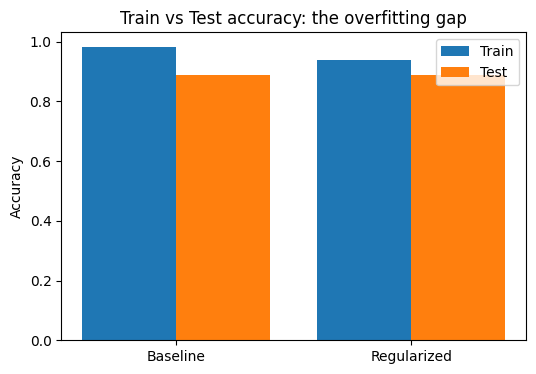

In [ ]:
# Visualise the gap
labels = ['Baseline', 'Regularized']
train_accs = [base_train_acc, reg_train_acc]
test_accs = [base_test_acc, reg_test_acc]
x = range(len(labels))
plt.figure(figsize=(6, 4))
plt.bar([i - 0.2 for i in x], train_accs, width=0.4, label='Train')
plt.bar([i + 0.2 for i in x], test_accs, width=0.4, label='Test')
plt.xticks(list(x), labels)
plt.ylabel('Accuracy')
plt.title('Train vs Test accuracy: the overfitting gap')
plt.legend()
plt.show()


## Takeaway

The baseline's train accuracy sits far above its test accuracy — a wide gap that means it memorized the training set. After adding **BatchNorm, Dropout, and weight decay (L2)** to the same `MyNN`, train accuracy drops a little but test accuracy holds up, so the **gap shrinks**. A smaller train-test gap means the model generalizes better — that is what regularization buys us.
